# 03 - Exploratory Data Analysis (EDA)

## Objectives

The objectives of this notebook are to explore the cleaned Walmart sales data, identify patterns and trends, and uncover business insights that can improve sales forecasting models.

Specifically, this notebook will:

- Analyze the distribution of weekly sales.
- Examine sales trends over time.
- Compare sales performance across stores and departments.
- Identify the best-performing and lowest-performing stores and departments.
- Analyze sales by store type and store size.
- Evaluate the impact of holidays on weekly sales.
- Investigate the relationship between promotional markdowns and sales.
- Explore the influence of temperature, fuel prices, CPI, and unemployment on sales.
- Detect seasonal patterns and long-term sales trends.
- Identify outliers and unusual sales behavior.
- Analyze correlations between numerical variables.
- Generate business insights that support feature engineering and forecasting model development.

## Expected Outcome

By the end of this notebook, we will have a clear understanding of the factors that influence Walmart's weekly sales. The insights gained from this analysis will help identify the most important predictors of sales, guide feature engineering, and improve the performance of the forecasting models developed in the following notebooks.

#### Import Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

train = pd.read_csv("../data/processed/train_clean.csv")

train["Date"] = pd.to_datetime(train["Date"])

### Distribution of Weekly Sales
#### Objective

Understand the distribution of the target variable (Weekly_Sales) by examining its statistical properties, identifying outliers, and assessing whether the data is skewed. This helps determine if transformations or special handling may be needed before model development.

#### Descriptive Statistics

In [2]:
train["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

#### Skewness

In [3]:
train["Weekly_Sales"].skew()

np.float64(3.2620081854656635)

#### Histogram

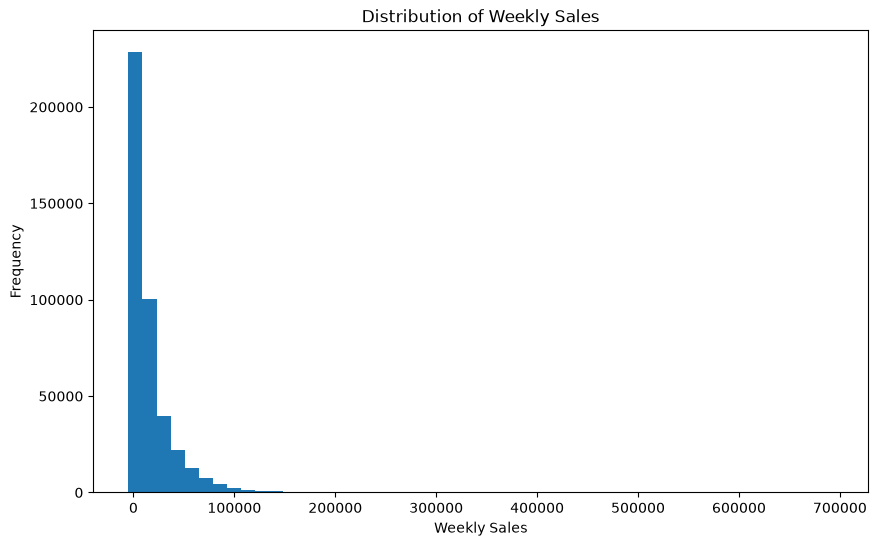

In [4]:
plt.figure(figsize=(10,6))

plt.hist(train["Weekly_Sales"], bins=50)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

#### Boxplot

C:\Users\user\AppData\Local\Temp\ipykernel_11256\182998545.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(train["Weekly_Sales"], vert=False)


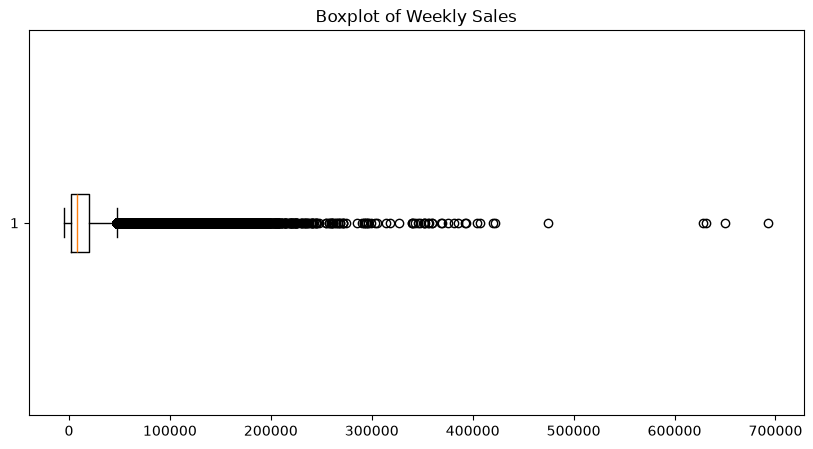

In [5]:
plt.figure(figsize=(10,5))

plt.boxplot(train["Weekly_Sales"], vert=False)

plt.title("Boxplot of Weekly Sales")

plt.show()

#### Negative Sales

In [6]:
negative_sales = train[train["Weekly_Sales"] < 0]

print("Negative Sales Records:", len(negative_sales))

Negative Sales Records: 1285


#### Sales Percentiles

In [7]:
train["Weekly_Sales"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25      2079.6500
0.50      7612.0300
0.75     20205.8525
0.90     42845.6730
0.95     61201.9510
0.99    106479.5860
Name: Weekly_Sales, dtype: float64

### Key Observations

- Weekly sales exhibit a right-skewed distribution.
- Most observations fall within relatively low to moderate sales ranges.
- A small number of records contain exceptionally high sales values, creating a long right tail.
- Negative sales values are present and likely represent returns or accounting adjustments rather than data errors.
- The presence of outliers should be considered during feature engineering and model evaluation, but they should not be removed without business justification.

### Business Insight

The distribution of weekly sales indicates that Walmart experiences substantial variability across stores and departments. While most weekly sales are moderate, occasional high-demand periods generate significantly larger sales volumes. These peaks are likely influenced by seasonal events, holidays, or promotional campaigns.

Forecasting models should therefore be capable of capturing both regular sales patterns and sudden spikes without being overly influenced by extreme observations.


### Weekly Sales Trend
#### Objective

Analyze the overall trend of weekly sales over time to identify long-term growth, seasonal fluctuations, and unusual sales spikes. Understanding these patterns is essential for selecting appropriate forecasting models and engineering time-based features.

In [93]:
#Aggregate Weekly Sales


weekly_sales = (
    train.groupby("Date")["Weekly_Sales"]
         .sum()
         .reset_index()
)

weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [9]:
weekly_sales.shape

(143, 2)

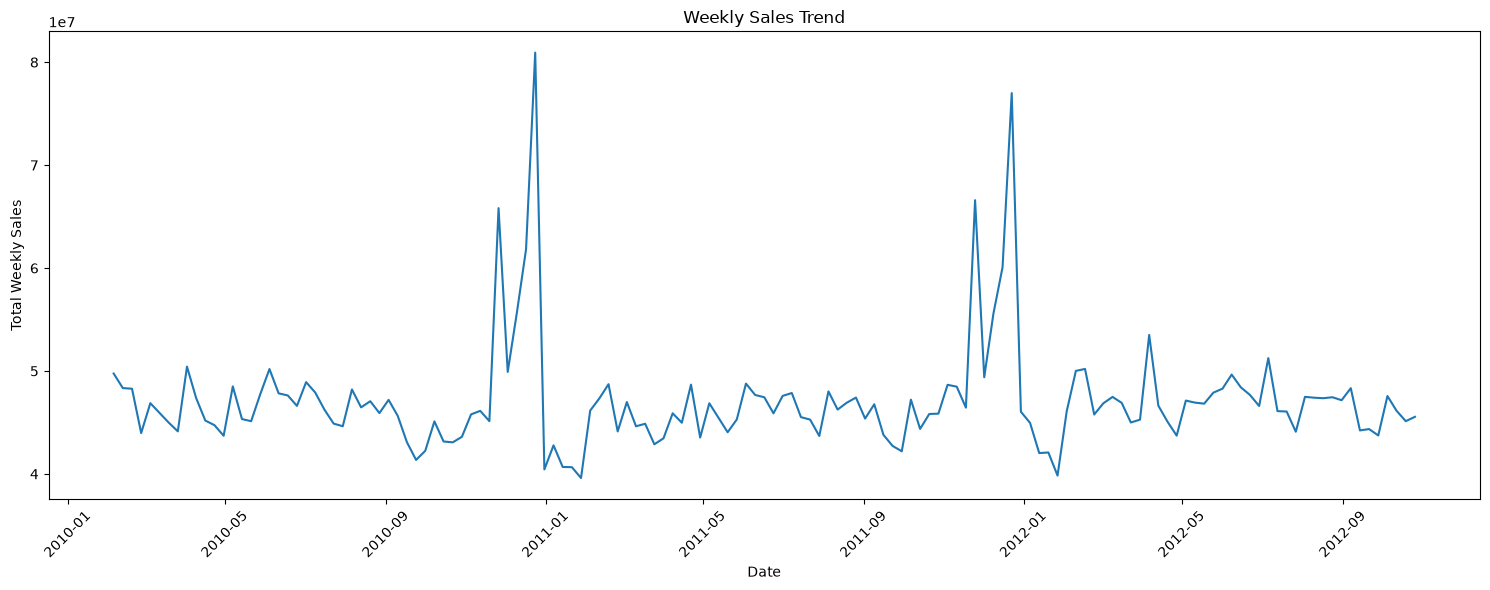

In [10]:
#Weekly Sales Trend Plot 

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"]
)

plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [11]:
#Highest Weekly Sales

weekly_sales.sort_values(
    "Weekly_Sales",
    ascending=False
).head(10)

,Date,Weekly_Sales
46,2010-12-24,80931415.60
98,2011-12-23,76998241.31
94,2011-11-25,66593605.26
42,2010-11-26,65821003.24
45,2010-12-17,61820799.85
97,2011-12-16,60085695.94
44,2010-12-10,55666770.39
96,2011-12-09,55561147.70
113,2012-04-06,53502315.87
126,2012-07-06,51253021.88


In [12]:
#Lowest Weekly Sales

weekly_sales.sort_values(
    "Weekly_Sales"
).head(10)

,Date,Weekly_Sales
51,2011-01-28,39599852.99
103,2012-01-27,39834974.67
47,2010-12-31,40432519.00
50,2011-01-21,40654648.03
49,2011-01-14,40673678.04
33,2010-09-24,41358514.41
101,2012-01-13,42023078.48
102,2012-01-20,42080996.56
86,2011-09-30,42195830.81
34,2010-10-01,42239875.87


In [13]:
#Average Weekly Sales

weekly_sales["Weekly_Sales"].mean()

np.float64(47113419.49027973)

In [14]:
#Maximum Weekly Sales

weekly_sales["Weekly_Sales"].max()

np.float64(80931415.6)

In [15]:
#Minimum Weekly Sales

weekly_sales["Weekly_Sales"].min()

np.float64(39599852.99)

In [16]:
#Rolling Average (4-Week Moving Average)

weekly_sales["Rolling_4_Weeks"] = (
    weekly_sales["Weekly_Sales"]
    .rolling(window=4)
    .mean()
)

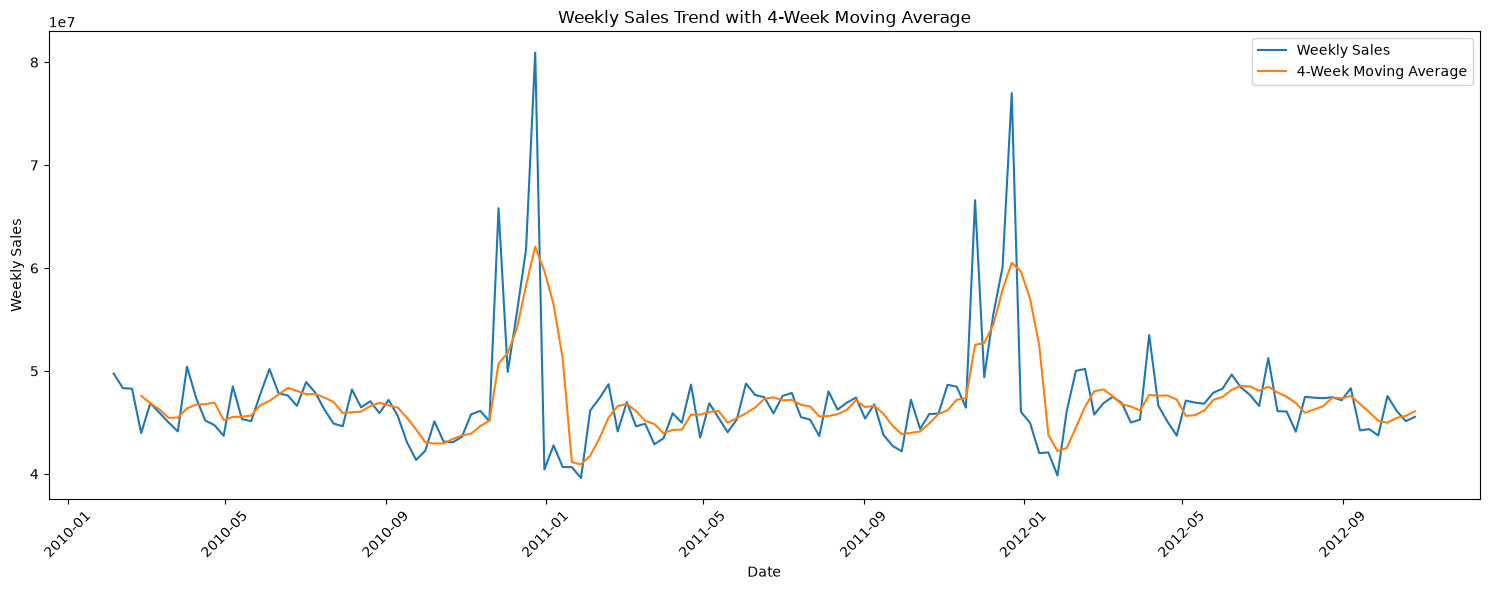

In [17]:
#Weekly Sales with Rolling Average Plot

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"],
    label="Weekly Sales"
)

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Rolling_4_Weeks"],
    label="4-Week Moving Average"
)

plt.title("Weekly Sales Trend with 4-Week Moving Average")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


In [18]:
#Peak Sales Weeks

weekly_sales.nlargest(
    5,
    "Weekly_Sales"
)

,Date,Weekly_Sales,Rolling_4_Weeks
46,2010-12-24,80931415.60,6.208200e+07
98,2011-12-23,76998241.31,6.050891e+07
94,2011-11-25,66593605.26,5.254059e+07
42,2010-11-26,65821003.24,5.071334e+07
45,2010-12-17,61820799.85,5.830440e+07


In [19]:
#Lowest Sales Weeks

weekly_sales.nsmallest(
    5,
    "Weekly_Sales"
)

,Date,Weekly_Sales,Rolling_4_Weeks
51,2011-01-28,39599852.99,4.092599e+07
103,2012-01-27,39834974.67,4.222362e+07
47,2010-12-31,40432519.00,5.971288e+07
50,2011-01-21,40654648.03,4.113416e+07
49,2011-01-14,40673678.04,5.120335e+07


#### Sales by Store

In [20]:
#Total Sales by Store

store_sales = (
    train.groupby("Store")["Weekly_Sales"]
         .sum()
         .reset_index()
         .sort_values("Weekly_Sales", ascending=False)
)

store_sales.head()

,Store,Weekly_Sales
19,20,3.013978e+08
3,4,2.995440e+08
13,14,2.889999e+08
12,13,2.865177e+08
1,2,2.753824e+08


In [21]:
#Top 10 Stores by Total Sales

store_sales.head(10)

,Store,Weekly_Sales
19,20,3.013978e+08
3,4,2.995440e+08
13,14,2.889999e+08
12,13,2.865177e+08
1,2,2.753824e+08
9,10,2.716177e+08
26,27,2.538559e+08
5,6,2.237561e+08
0,1,2.224028e+08
38,39,2.074455e+08


In [22]:
#Bottom 10 Stores by Total Sales

store_sales.tail(10)

,Store,Weekly_Sales
28,29,77141554.31
15,16,74252425.40
36,37,74202740.32
29,30,62716885.12
2,3,57586735.07
37,38,55159626.42
35,36,53412214.97
4,5,45475688.90
43,44,43293087.84
32,33,37160221.96


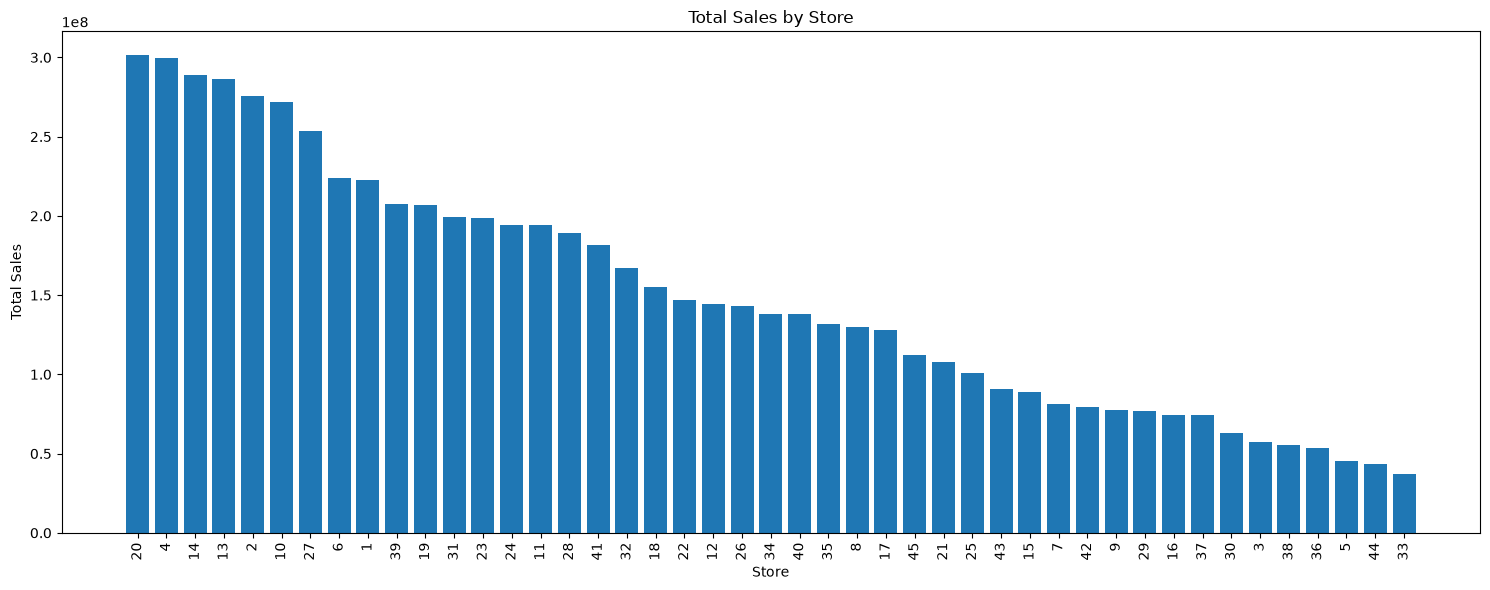

In [23]:
#Total Sales by Store Plot

plt.figure(figsize=(15,6))

plt.bar(
    store_sales["Store"].astype(str),
    store_sales["Weekly_Sales"]
)

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [24]:
#Average Weekly Sales by Store

average_store_sales = (
    train.groupby("Store")["Weekly_Sales"]
         .mean()
         .reset_index()
         .sort_values("Weekly_Sales", ascending=False)
)

average_store_sales.head()

,Store,Weekly_Sales
19,20,29508.301592
3,4,29161.210415
13,14,28784.851727
12,13,27355.136891
1,2,26898.070031


In [25]:
#Top 10 Stores by Average Weekly Sales

average_store_sales.head(10)

,Store,Weekly_Sales
19,20,29508.301592
3,4,29161.210415
13,14,28784.851727
12,13,27355.136891
1,2,26898.070031
9,10,26332.303819
26,27,24826.984536
5,6,21913.243624
0,1,21710.543621
38,39,21000.763562


In [26]:
#Bottom 10 Stores by Average Weekly Sales

average_store_sales.tail(10)

,Store,Weekly_Sales
29,30,8764.237719
35,36,8584.412563
6,7,8358.766148
28,29,8158.810609
15,16,7863.224124
37,38,7492.478460
2,3,6373.033983
43,44,6038.929814
32,33,5728.414053
4,5,5053.415813


In [27]:
#Comparing Store Size and Sales
store_summary = (
    train.groupby(["Store", "Type", "Size"], as_index=False)
         .agg(
             Total_Sales=("Weekly_Sales", "sum"),
             Average_Weekly_Sales=("Weekly_Sales", "mean")
         )
)

store_summary.head()

,Store,Type,Size,Total_Sales,Average_Weekly_Sales
0,1,A,151315,2.224028e+08,21710.543621
1,2,A,202307,2.753824e+08,26898.070031
2,3,B,37392,5.758674e+07,6373.033983
3,4,A,205863,2.995440e+08,29161.210415
4,5,B,34875,4.547569e+07,5053.415813


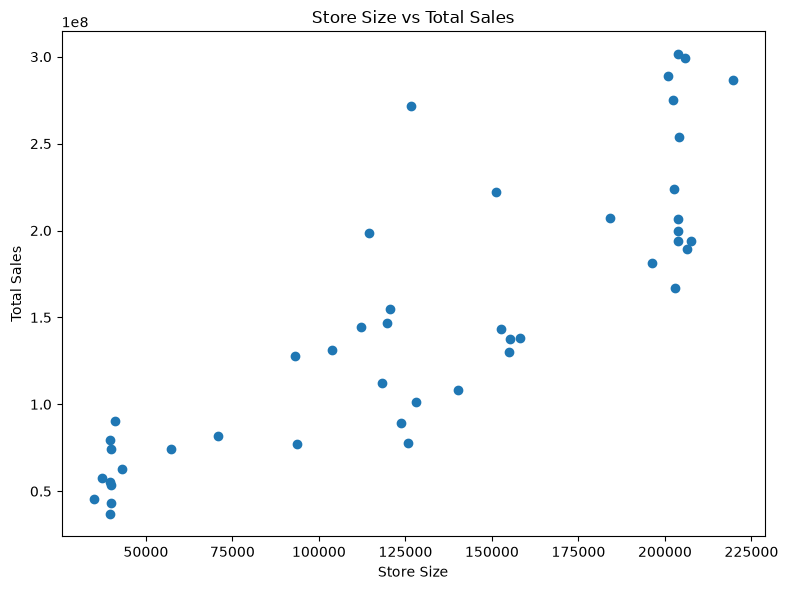

In [28]:
#Relationship Between Store Size and Total Sales

plt.figure(figsize=(8,6))

plt.scatter(
    store_summary["Size"],
    store_summary["Total_Sales"]
)

plt.title("Store Size vs Total Sales")
plt.xlabel("Store Size")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

In [29]:
#Top 5 Highest Revenue Stores

store_summary.nlargest(
    5,
    "Total_Sales"
)


,Store,Type,Size,Total_Sales,Average_Weekly_Sales
19,20,A,203742,3.013978e+08,29508.301592
3,4,A,205863,2.995440e+08,29161.210415
13,14,A,200898,2.889999e+08,28784.851727
12,13,A,219622,2.865177e+08,27355.136891
1,2,A,202307,2.753824e+08,26898.070031


In [30]:
#Top 5 Lowest Revenue Stores

store_summary.nsmallest(
    5,
    "Total_Sales"
)

,Store,Type,Size,Total_Sales,Average_Weekly_Sales
32,33,A,39690,37160221.96,5728.414053
43,44,C,39910,43293087.84,6038.929814
4,5,B,34875,45475688.90,5053.415813
35,36,A,39910,53412214.97,8584.412563
37,38,C,39690,55159626.42,7492.478460


In [31]:
#Store Contribution to Total Sales

store_summary["Sales_Percentage"] = (
    store_summary["Total_Sales"]
    / store_summary["Total_Sales"].sum()
) * 100

store_summary.sort_values(
    "Sales_Percentage",
    ascending=False
).head(10)

,Store,Type,Size,Total_Sales,Average_Weekly_Sales,Sales_Percentage
19,20,A,203742,3.013978e+08,29508.301592,4.473623
3,4,A,205863,2.995440e+08,29161.210415,4.446107
13,14,A,200898,2.889999e+08,28784.851727,4.289602
12,13,A,219622,2.865177e+08,27355.136891,4.252759
1,2,A,202307,2.753824e+08,26898.070031,4.087479
9,10,B,126512,2.716177e+08,26332.303819,4.031600
26,27,A,204184,2.538559e+08,24826.984536,3.767963
5,6,A,202505,2.237561e+08,21913.243624,3.321194
0,1,A,151315,2.224028e+08,21710.543621,3.301107
38,39,A,184109,2.074455e+08,21000.763562,3.079098


In [32]:
#Descriptive Statistics

store_summary[[
    "Total_Sales",
    "Average_Weekly_Sales"
]].describe()

,Total_Sales,Average_Weekly_Sales
count,4.500000e+01,45.000000
mean,1.497160e+08,15438.091939
std,7.816756e+07,7011.232951
min,3.716022e+07,5053.415813
25%,7.956575e+07,9002.493073
50%,1.382498e+08,13803.596986
75%,1.996139e+08,19776.180881
max,3.013978e+08,29508.301592


#### Sales by Department

In [33]:
#Total Sales by Department

department_sales = (
    train.groupby("Dept")["Weekly_Sales"]
         .sum()
         .reset_index()
         .sort_values("Weekly_Sales", ascending=False)
)

department_sales.head()

,Dept,Weekly_Sales
73,92,4.839433e+08
76,95,4.493202e+08
36,38,3.931181e+08
60,72,3.057252e+08
71,90,2.910685e+08


In [34]:
#Top 10 Departments

department_sales.head(10)

,Dept,Weekly_Sales
73,92,4.839433e+08
76,95,4.493202e+08
36,38,3.931181e+08
60,72,3.057252e+08
71,90,2.910685e+08
38,40,2.889360e+08
1,2,2.806112e+08
72,91,2.167817e+08
12,13,1.973216e+08
7,8,1.942808e+08


In [35]:
#Bottom 10 Departments

department_sales.tail(10)

,Dept,Weekly_Sales
56,60,2005020.96
51,54,516294.63
80,99,358149.85
62,77,49344.27
43,45,44937.63
49,51,30572.83
63,78,1714.71
37,39,177.98
41,43,14.32
45,47,-4962.93


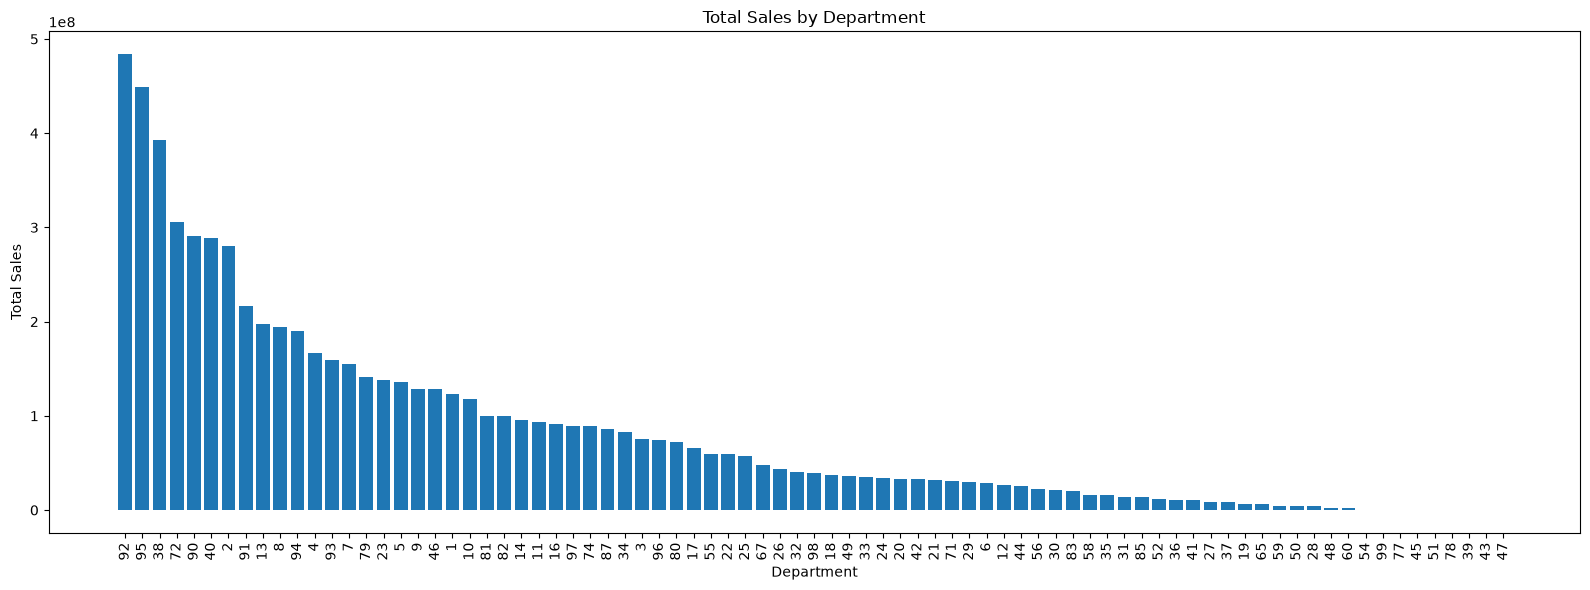

In [36]:
#Total Sales by Department Plot
plt.figure(figsize=(16,6))

plt.bar(
    department_sales["Dept"].astype(str),
    department_sales["Weekly_Sales"]
)

plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [37]:
#Average Weekly Sales by Department

average_department_sales = (
    train.groupby("Dept")["Weekly_Sales"]
         .mean()
         .reset_index()
         .sort_values("Weekly_Sales", ascending=False)
)

average_department_sales.head()

,Dept,Weekly_Sales
73,92,75204.870531
76,95,69824.423080
36,38,61090.619568
60,72,50566.515417
57,65,45441.706224


In [38]:
#Top 10 Departments by Average Weekly Sales

average_department_sales.head(10)

,Dept,Weekly_Sales
73,92,75204.870531
76,95,69824.423080
36,38,61090.619568
60,72,50566.515417
57,65,45441.706224
71,90,45232.084488
38,40,44900.702727
1,2,43607.020113
72,91,33687.910758
75,94,33405.883963


In [39]:
#Bottom 10 Departments by Average Weekly Sales

average_department_sales.tail(10)

,Dept,Weekly_Sales
80,99,415.487065
56,60,347.370229
62,77,328.961800
51,54,108.305985
43,45,23.211586
49,51,21.931729
37,39,11.123750
63,78,7.296638
41,43,1.193333
45,47,-7.682554


In [40]:
#Department Sales Contribution

department_sales["Sales_Percentage"] = (
    department_sales["Weekly_Sales"]
    / department_sales["Weekly_Sales"].sum()
) * 100

department_sales.head()

,Dept,Weekly_Sales,Sales_Percentage
73,92,4.839433e+08,7.183132
76,95,4.493202e+08,6.669223
36,38,3.931181e+08,5.835021
60,72,3.057252e+08,4.537854
71,90,2.910685e+08,4.320306


In [41]:
#Top 10 Department Contribution

department_sales.head(10)

,Dept,Weekly_Sales,Sales_Percentage
73,92,4.839433e+08,7.183132
76,95,4.493202e+08,6.669223
36,38,3.931181e+08,5.835021
60,72,3.057252e+08,4.537854
71,90,2.910685e+08,4.320306
38,40,2.889360e+08,4.288654
1,2,2.806112e+08,4.165089
72,91,2.167817e+08,3.217673
12,13,1.973216e+08,2.928828
7,8,1.942808e+08,2.883694


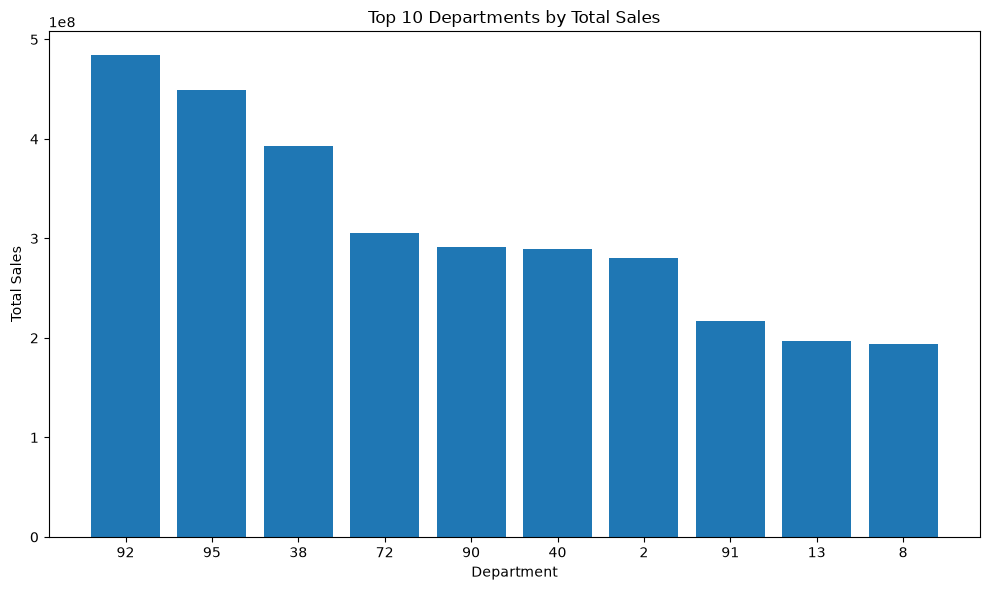

In [42]:
#Top 10 Departments Plot

top10_departments = department_sales.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10_departments["Dept"].astype(str),
    top10_departments["Weekly_Sales"]
)

plt.title("Top 10 Departments by Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

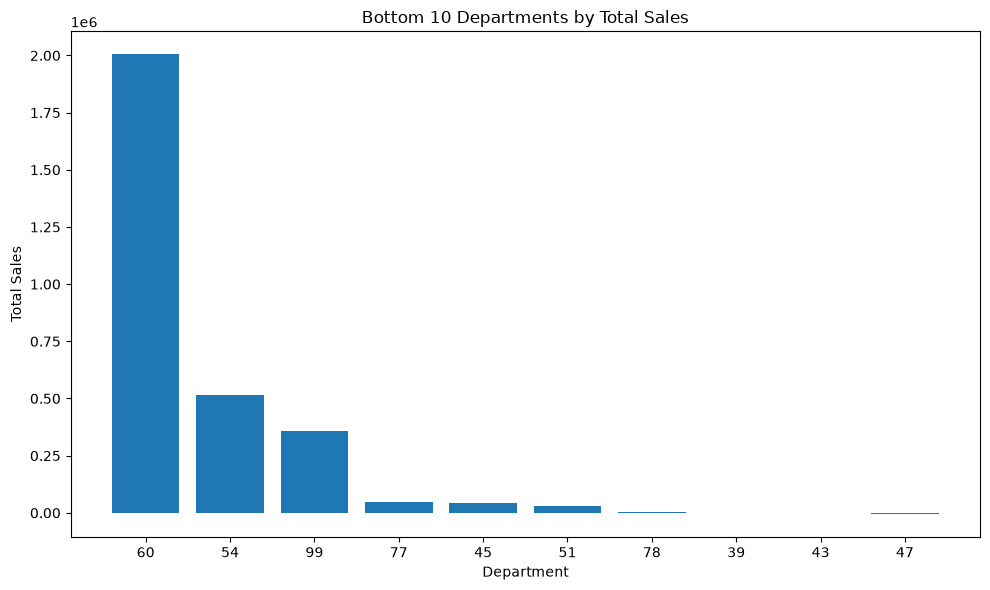

In [43]:
#Plot Bottom 10 Departments

bottom10_departments = department_sales.tail(10)

plt.figure(figsize=(10,6))

plt.bar(
    bottom10_departments["Dept"].astype(str),
    bottom10_departments["Weekly_Sales"]
)

plt.title("Bottom 10 Departments by Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

In [44]:
#Department Statistics

department_sales["Weekly_Sales"].describe()

count    8.100000e+01
mean     8.317554e+07
std      1.035439e+08
min     -4.962930e+03
25%      1.208694e+07
50%      3.982892e+07
75%      1.178974e+08
max      4.839433e+08
Name: Weekly_Sales, dtype: float64

In [45]:
#Highest Revenue Department

department_sales.iloc[0]

Dept                9.200000e+01
Weekly_Sales        4.839433e+08
Sales_Percentage    7.183132e+00
Name: 73, dtype: float64

In [46]:
#Lowest Revenue Department

department_sales.iloc[-1]

Dept                  47.000000
Weekly_Sales       -4962.930000
Sales_Percentage      -0.000074
Name: 45, dtype: float64

#### Sales by Store Type

In [47]:
#Number of Stores by Type

store_type_count = (
    train[["Store", "Type"]]
    .drop_duplicates()
    .groupby("Type")
    .size()
    .reset_index(name="Number_of_Stores")
)

store_type_count

,Type,Number_of_Stores
0,A,22
1,B,17
2,C,6


In [48]:
#Total Sales by Store Type

sales_by_type = (
    train.groupby("Type")["Weekly_Sales"]
         .sum()
         .reset_index()
         .sort_values("Weekly_Sales", ascending=False)
)

sales_by_type

,Type,Weekly_Sales
0,A,4.331015e+09
1,B,2.000701e+09
2,C,4.055035e+08


In [49]:
#Average Weekly Sales by Store Type

avg_sales_by_type = (
    train.groupby("Type")["Weekly_Sales"]
         .mean()
         .reset_index()
         .sort_values("Weekly_Sales", ascending=False)
)

avg_sales_by_type

,Type,Weekly_Sales
0,A,20099.568043
1,B,12237.075977
2,C,9519.532538


In [50]:
#Average Store Size by Type

store_size = (
    train.groupby("Type")["Size"]
         .mean()
         .reset_index()
         .sort_values("Size", ascending=False)
)

store_size

,Type,Size
0,A,182231.285486
1,B,101818.735827
2,C,40535.725286


In [51]:
#Store Type Summary

store_type_summary = (
    train.groupby("Type")
         .agg(
             Total_Sales=("Weekly_Sales", "sum"),
             Average_Weekly_Sales=("Weekly_Sales", "mean"),
             Average_Store_Size=("Size", "mean"),
             Number_of_Records=("Weekly_Sales", "count")
         )
         .reset_index()
)

store_type_summary

,Type,Total_Sales,Average_Weekly_Sales,Average_Store_Size,Number_of_Records
0,A,4.331015e+09,20099.568043,182231.285486,215478
1,B,2.000701e+09,12237.075977,101818.735827,163495
2,C,4.055035e+08,9519.532538,40535.725286,42597


In [52]:
#Sales Contribution by Store Type

store_type_summary["Sales_Percentage"] = (
    store_type_summary["Total_Sales"]
    / store_type_summary["Total_Sales"].sum()
) * 100

store_type_summary

,Type,Total_Sales,Average_Weekly_Sales,Average_Store_Size,Number_of_Records,Sales_Percentage
0,A,4.331015e+09,20099.568043,182231.285486,215478,64.284903
1,B,2.000701e+09,12237.075977,101818.735827,163495,29.696240
2,C,4.055035e+08,9519.532538,40535.725286,42597,6.018856


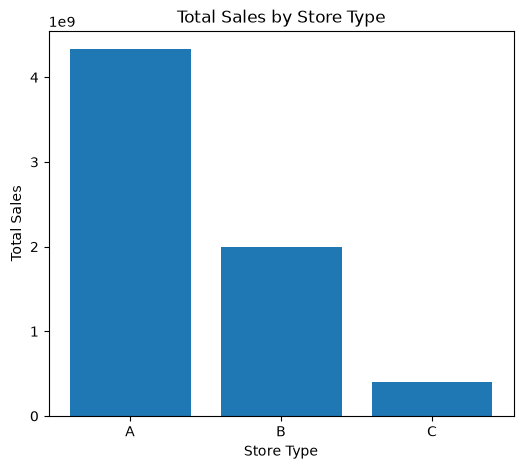

In [53]:
#Bar Chart — Total Sales by Store Type

plt.figure(figsize=(6,5))

plt.bar(
    sales_by_type["Type"],
    sales_by_type["Weekly_Sales"]
)

plt.title("Total Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Total Sales")

plt.show()

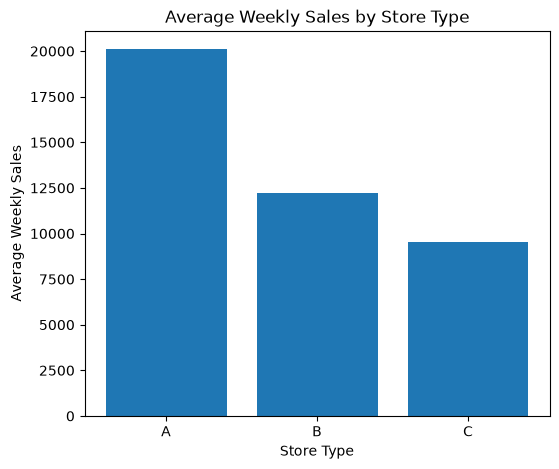

In [54]:
#Bar Chart — Average Weekly Sales by Store Type

plt.figure(figsize=(6,5))

plt.bar(
    avg_sales_by_type["Type"],
    avg_sales_by_type["Weekly_Sales"]
)

plt.title("Average Weekly Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")

plt.show()

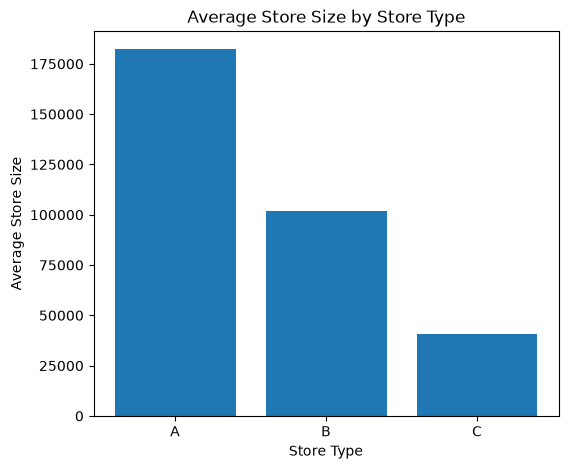

In [55]:
#Bar Chart — Average Store Size

plt.figure(figsize=(6,5))

plt.bar(
    store_size["Type"],
    store_size["Size"]
)

plt.title("Average Store Size by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Store Size")

plt.show()

In [56]:
#Summary Statistics

store_type_summary.describe()

,Total_Sales,Average_Weekly_Sales,Average_Store_Size,Number_of_Records,Sales_Percentage
count,3.000000e+00,3.000000,3.000000,3.000000,3.000000
mean,2.245740e+09,13952.058853,108195.248866,140523.333333,33.333333
std,1.974194e+09,5494.557536,71062.668709,88700.243192,29.302805
min,4.055035e+08,9519.532538,40535.725286,42597.000000,6.018856
25%,1.203102e+09,10878.304258,71177.230556,103046.000000,17.857548
50%,2.000701e+09,12237.075977,101818.735827,163495.000000,29.696240
75%,3.165858e+09,16168.322010,142025.010657,189486.500000,46.990572
max,4.331015e+09,20099.568043,182231.285486,215478.000000,64.284903


#### Holiday Impact Analysis

In [57]:
#Holiday Distribution

train["IsHoliday"].value_counts()

IsHoliday
False    391909
True      29661
Name: count, dtype: int64

In [58]:
#Percentage of Holiday vs Non-Holiday Records

(
    train["IsHoliday"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

IsHoliday
False    92.96
True      7.04
Name: proportion, dtype: float64

In [59]:
#Total Sales by Holiday Status

holiday_sales = (
    train.groupby("IsHoliday")["Weekly_Sales"]
         .sum()
         .reset_index()
)

holiday_sales

,IsHoliday,Weekly_Sales
0,False,6.231919e+09
1,True,5.052996e+08


In [60]:
#Average Weekly Sales by Holiday Status

average_holiday_sales = (
    train.groupby("IsHoliday")["Weekly_Sales"]
         .mean()
         .reset_index()
)

average_holiday_sales

,IsHoliday,Weekly_Sales
0,False,15901.445069
1,True,17035.823187


In [61]:
#Median Weekly Sales

median_holiday_sales = (
    train.groupby("IsHoliday")["Weekly_Sales"]
         .median()
         .reset_index()
)

median_holiday_sales

,IsHoliday,Weekly_Sales
0,False,7589.95
1,True,7947.74


In [62]:
#Summary Statistics

train.groupby("IsHoliday")["Weekly_Sales"].describe()

,count,mean,std,min,25%,50%,75%,max
IsHoliday,,,,,,,,
False,391909.0,15901.445069,22330.747450,-4988.94,2079.75,7589.95,20131.21,406988.63
True,29661.0,17035.823187,27222.000409,-798.00,2078.54,7947.74,21189.25,693099.36


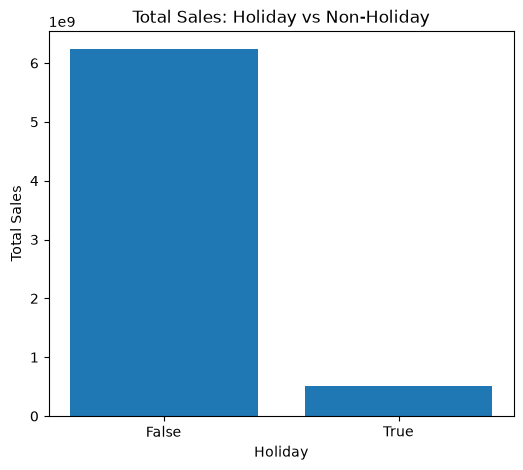

In [63]:
#Compare Holiday Sales

plt.figure(figsize=(6,5))

plt.bar(
    holiday_sales["IsHoliday"].astype(str),
    holiday_sales["Weekly_Sales"]
)

plt.title("Total Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday")
plt.ylabel("Total Sales")

plt.show()

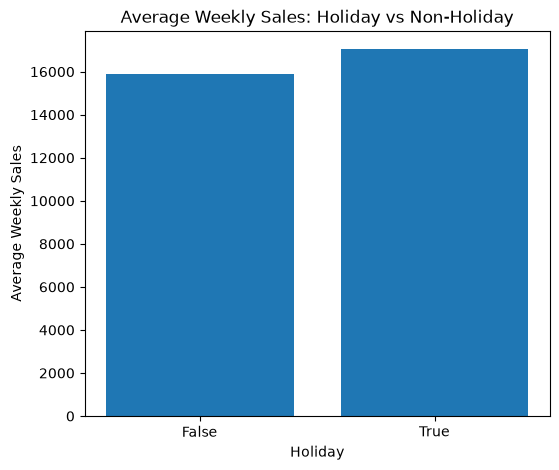

In [64]:
#Compare Average Weekly Sales

plt.figure(figsize=(6,5))

plt.bar(
    average_holiday_sales["IsHoliday"].astype(str),
    average_holiday_sales["Weekly_Sales"]
)

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Weekly Sales")

plt.show()

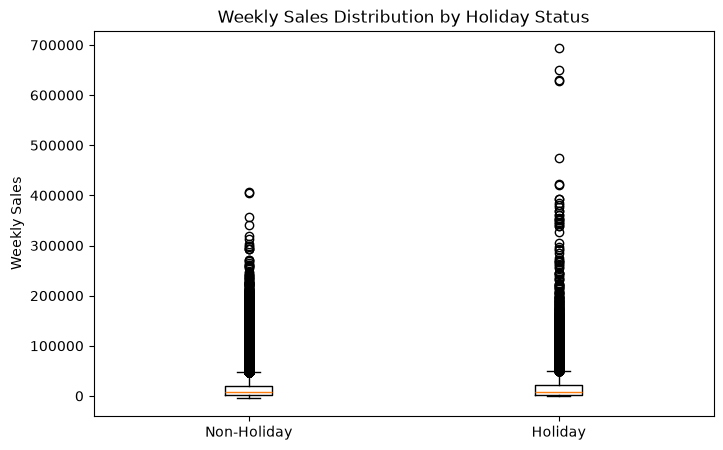

In [65]:
#Sales Distribution by Holiday Status

plt.figure(figsize=(8,5))

plt.boxplot(
    [
        train.loc[train["IsHoliday"] == False, "Weekly_Sales"],
        train.loc[train["IsHoliday"] == True, "Weekly_Sales"]
    ],
    tick_labels=["Non-Holiday", "Holiday"]
)

plt.title("Weekly Sales Distribution by Holiday Status")
plt.ylabel("Weekly Sales")

plt.show()

In [66]:
#Holiday Sales Difference

holiday_avg = train.loc[
    train["IsHoliday"],
    "Weekly_Sales"
].mean()

nonholiday_avg = train.loc[
    ~train["IsHoliday"],
    "Weekly_Sales"
].mean()

percentage_change = (
    (holiday_avg - nonholiday_avg)
    / nonholiday_avg
) * 100

print(f"Holiday Average Sales: {holiday_avg:,.2f}")
print(f"Non-Holiday Average Sales: {nonholiday_avg:,.2f}")
print(f"Percentage Difference: {percentage_change:.2f}%")

Holiday Average Sales: 17,035.82
Non-Holiday Average Sales: 15,901.45
Percentage Difference: 7.13%


In [67]:
#Identify Highest Sales Holiday Weeks

(
    train.loc[train["IsHoliday"]]
         .groupby("Date")["Weekly_Sales"]
         .sum()
         .sort_values(ascending=False)
)

Date
2011-11-25    66593605.26
2010-11-26    65821003.24
2012-02-10    50009407.92
2010-02-12    48336677.63
2012-09-07    48330059.31
2011-02-11    47336192.79
2011-09-09    46763227.53
2011-12-30    46042461.04
2010-09-10    45634397.84
2010-12-31    40432519.00
Name: Weekly_Sales, dtype: float64

#### Relationship Between Sales and External Factors

In [68]:
#Correlation Matrix

correlation = train[
    [
        "Weekly_Sales",
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment"
    ]
].corr()

correlation

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
Weekly_Sales,1.000000,-0.002312,-0.000120,-0.020921,-0.025864
Temperature,-0.002312,1.000000,0.143859,0.182112,0.096730
Fuel_Price,-0.000120,0.143859,1.000000,-0.164210,-0.033853
CPI,-0.020921,0.182112,-0.164210,1.000000,-0.299953
Unemployment,-0.025864,0.096730,-0.033853,-0.299953,1.000000


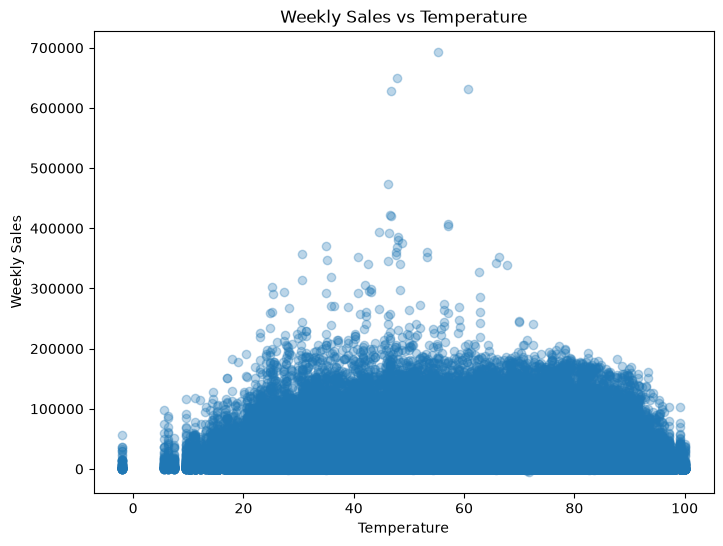

In [69]:
#Weekly Sales vs Temperature

plt.figure(figsize=(8,6))

plt.scatter(
    train["Temperature"],
    train["Weekly_Sales"],
    alpha=0.3
)

plt.title("Weekly Sales vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.show()

In [70]:
#Correlation

train["Weekly_Sales"].corr(train["Temperature"])

np.float64(-0.002312447010259374)

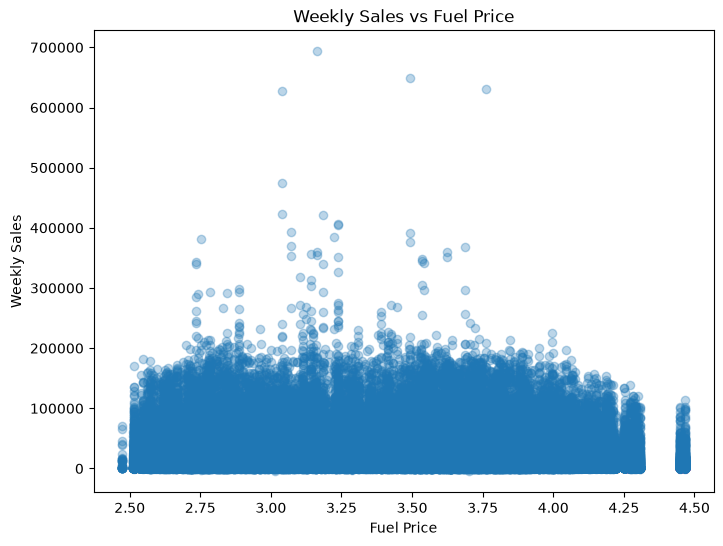

In [71]:
#Weekly Sales vs Fuel Price

plt.figure(figsize=(8,6))

plt.scatter(
    train["Fuel_Price"],
    train["Weekly_Sales"],
    alpha=0.3
)

plt.title("Weekly Sales vs Fuel Price")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")

plt.show()

In [72]:
#Correlation

train["Weekly_Sales"].corr(train["Fuel_Price"])

np.float64(-0.00012029554499574324)

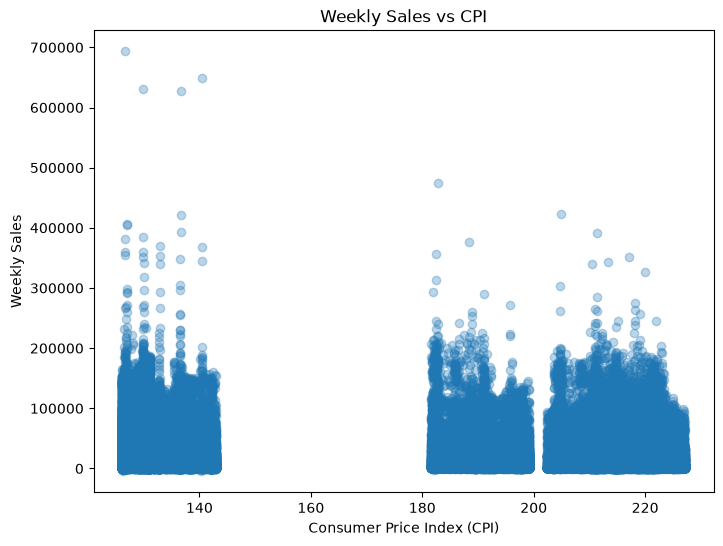

In [73]:
#Weekly Sales vs CPI

plt.figure(figsize=(8,6))

plt.scatter(
    train["CPI"],
    train["Weekly_Sales"],
    alpha=0.3
)

plt.title("Weekly Sales vs CPI")
plt.xlabel("Consumer Price Index (CPI)")
plt.ylabel("Weekly Sales")

plt.show()

In [74]:
#Correlation

train["Weekly_Sales"].corr(train["CPI"])

np.float64(-0.020921335318819168)

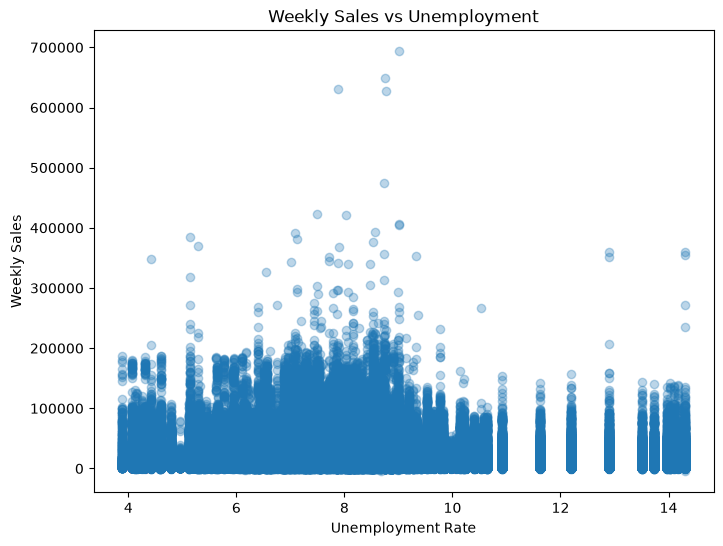

In [75]:
#Weekly Sales vs Unemployment

plt.figure(figsize=(8,6))

plt.scatter(
    train["Unemployment"],
    train["Weekly_Sales"],
    alpha=0.3
)

plt.title("Weekly Sales vs Unemployment")
plt.xlabel("Unemployment Rate")
plt.ylabel("Weekly Sales")

plt.show()

In [76]:
#Correlation

train["Weekly_Sales"].corr(train["Unemployment"])

np.float64(-0.025863716499837704)

In [77]:
#Summary Correlation Table

correlation_with_sales = (
    correlation["Weekly_Sales"]
    .sort_values(ascending=False)
    .to_frame(name="Correlation")
)

correlation_with_sales

,Correlation
Weekly_Sales,1.000000
Fuel_Price,-0.000120
Temperature,-0.002312
CPI,-0.020921
Unemployment,-0.025864


#### Time-Based Analysis & Seasonality

In [78]:
#Time Features

train["Year"] = train["Date"].dt.year
train["Quarter"] = train["Date"].dt.quarter
train["Month"] = train["Date"].dt.month
train["Week"] = train["Date"].dt.isocalendar().week.astype(int)

In [79]:
#Monthly Sales Trend

monthly_sales = (
    train.groupby("Month")["Weekly_Sales"]
         .sum()
         .reset_index()
)

monthly_sales

,Month,Weekly_Sales
0,1,3.325984e+08
1,2,5.687279e+08
2,3,5.927859e+08
3,4,6.468598e+08
4,5,5.571256e+08
5,6,6.226299e+08
6,7,6.500010e+08
7,8,6.130902e+08
8,9,5.787612e+08
9,10,5.847848e+08


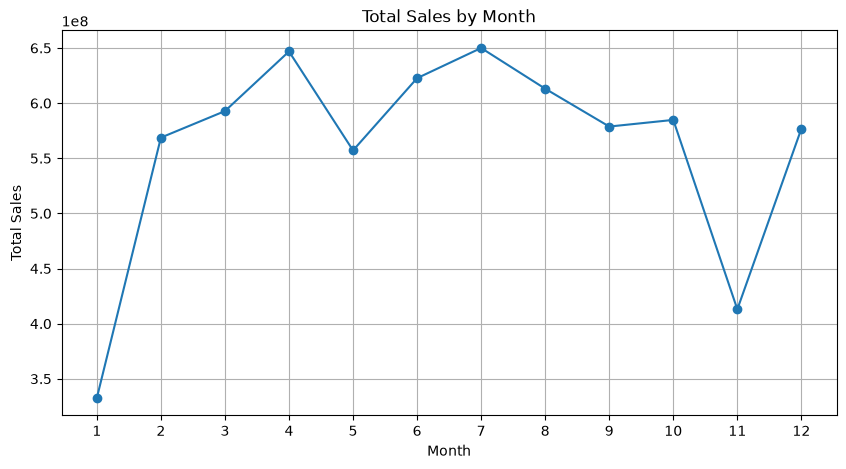

In [80]:
#Monthly Sales Chart

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Weekly_Sales"],
    marker="o"
)

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1,13))

plt.grid(True)

plt.show()

In [81]:
#Yearly Sales Trend

yearly_sales = (
    train.groupby("Year")["Weekly_Sales"]
         .sum()
         .reset_index()
)

yearly_sales

,Year,Weekly_Sales
0,2010,2.288886e+09
1,2011,2.448200e+09
2,2012,2.000133e+09


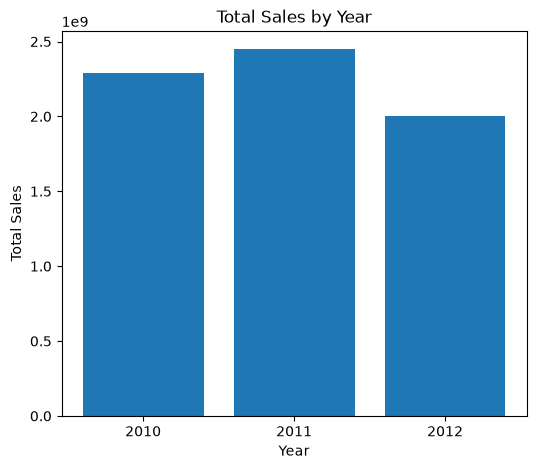

In [82]:
#Plot Yearly Sales

plt.figure(figsize=(6,5))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["Weekly_Sales"]
)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

In [83]:
#Quarterly Sales

quarterly_sales = (
    train.groupby("Quarter")["Weekly_Sales"]
         .sum()
         .reset_index()
)

quarterly_sales

,Quarter,Weekly_Sales
0,1,1.494112e+09
1,2,1.826615e+09
2,3,1.841852e+09
3,4,1.574639e+09


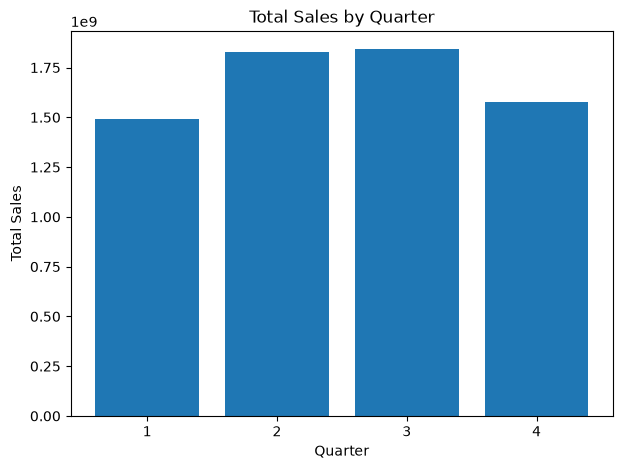

In [84]:
#Quarterly Sales Chart

plt.figure(figsize=(7,5))

plt.bar(
    quarterly_sales["Quarter"].astype(str),
    quarterly_sales["Weekly_Sales"]
)

plt.title("Total Sales by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.show()

In [85]:
#Weekly Seasonality

weekly_pattern = (
    train.groupby("Week")["Weekly_Sales"]
         .mean()
         .reset_index()
)

weekly_pattern.head()

,Week,Weekly_Sales
0,1,14862.139543
1,2,14030.667886
2,3,14077.870442
3,4,13530.033667
4,5,16029.516788


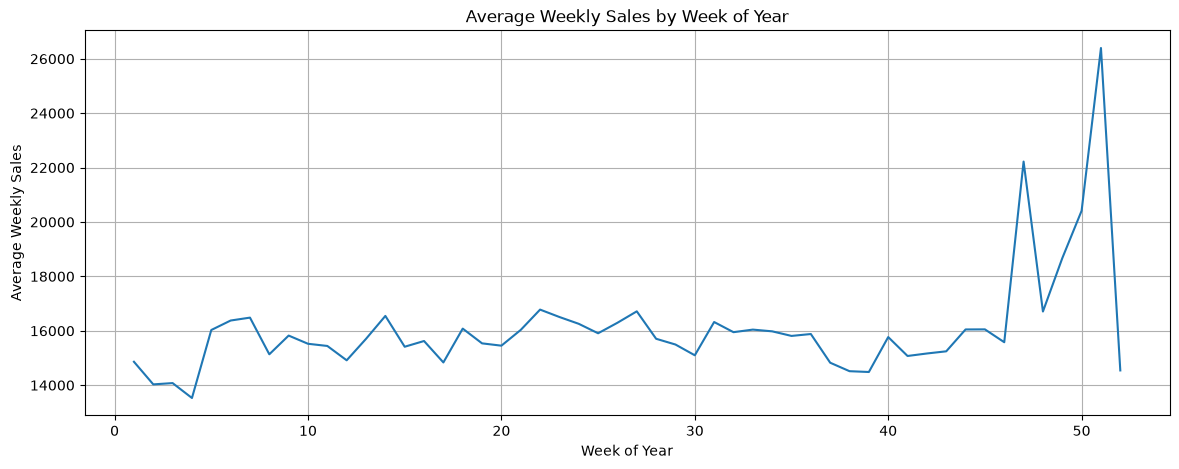

In [86]:
#Weekly Seasonality Chart

plt.figure(figsize=(14,5))

plt.plot(
    weekly_pattern["Week"],
    weekly_pattern["Weekly_Sales"]
)

plt.title("Average Weekly Sales by Week of Year")
plt.xlabel("Week of Year")
plt.ylabel("Average Weekly Sales")

plt.grid(True)

plt.show()

In [87]:
#Highest Sales Months

monthly_sales.sort_values(
    "Weekly_Sales",
    ascending=False
).head()

,Month,Weekly_Sales
6,7,6.500010e+08
3,4,6.468598e+08
5,6,6.226299e+08
7,8,6.130902e+08
2,3,5.927859e+08


In [88]:
#Lowest Sales Months

monthly_sales.sort_values(
    "Weekly_Sales"
).head()

,Month,Weekly_Sales
0,1,3.325984e+08
10,11,4.130157e+08
4,5,5.571256e+08
1,2,5.687279e+08
11,12,5.768386e+08


In [89]:
#Highest Sales Quarters

quarterly_sales.sort_values(
    "Weekly_Sales",
    ascending=False
)

,Quarter,Weekly_Sales
2,3,1.841852e+09
1,2,1.826615e+09
3,4,1.574639e+09
0,1,1.494112e+09


In [90]:
#Monthly Average Sales

monthly_average = (
    train.groupby("Month")["Weekly_Sales"]
         .mean()
         .reset_index()
)

monthly_average

,Month,Weekly_Sales
0,1,14126.075111
1,2,16008.779217
2,3,15416.657597
3,4,15650.338357
4,5,15776.337202
5,6,16326.137002
6,7,15861.419650
7,8,16062.516933
8,9,15095.886154
9,10,15243.855576


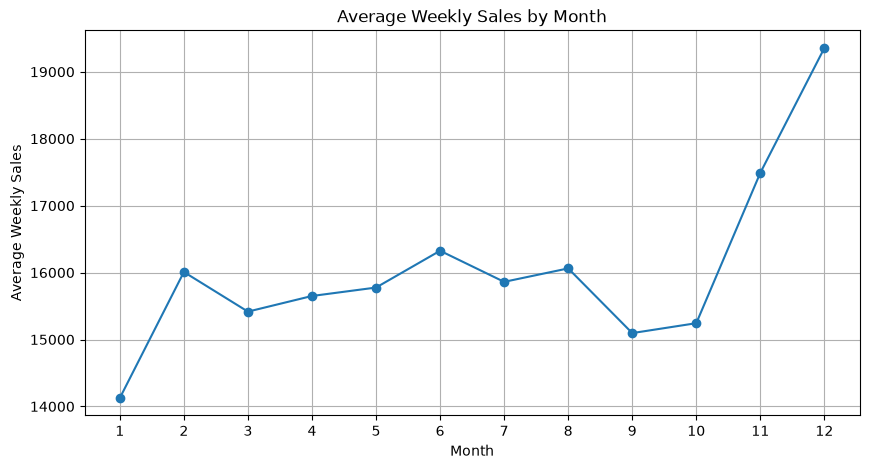

In [91]:
#Monthly Average Sales Plot
 
plt.figure(figsize=(10,5))

plt.plot(
    monthly_average["Month"],
    monthly_average["Weekly_Sales"],
    marker="o"
)

plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")

plt.xticks(range(1,13))

plt.grid(True)

plt.show()

### Key Observations

- Weekly sales exhibit a right-skewed distribution with several high-value outliers.
- Sales show clear seasonal patterns, particularly during holiday periods and the fourth quarter.
- Store performance varies significantly, with a small number of stores contributing a large share of total revenue.
- Department-level sales are highly uneven, indicating that demand differs across product categories.
- Type A stores generally outperform Type B and Type C stores in both total and average weekly sales.
- Holiday weeks consistently generate higher sales than non-holiday weeks.
- External variables such as Temperature, Fuel Price, CPI, and Unemployment have relatively weak individual linear relationships with weekly sales.
- Time-based features (Month, Quarter, Week, Holiday) appear to be much stronger predictors of sales than macroeconomic variables.
- The dataset is clean, well-structured, and suitable for forecasting after feature engineering.

### Executive Summary

The exploratory data analysis provided a comprehensive understanding of Walmart's historical sales patterns and the factors influencing customer demand. Sales vary substantially across stores, departments, store types, and time periods, with strong seasonal effects observed during holiday periods and year-end shopping seasons.

Although external economic indicators such as Temperature, Fuel Price, CPI, and Unemployment show relatively weak individual correlations with sales, they provide valuable contextual information and may improve forecasting performance when combined with historical sales and calendar-based features.

Overall, the analysis confirms that historical sales, temporal variables, holiday indicators, and store characteristics are the primary drivers of demand. These findings establish a solid foundation for the next stage of the project, where additional predictive features will be engineered to improve the accuracy of forecasting models.